# Crypto News Sentiment vs. BTC Price Movement

**Hypothesis test**:
is there a statistically detectable relationship between BTC-related news
sentiment and BTC price movement over 2024? Grounded in real
news-aggregation experience at TheCoinZone (CryptoCompare/CoinDesk) and GenAI-based
sentiment labeling.

**This is a hypothesis test, not a trading model.** No predictive up/down
classifier or trading-strategy claim appears anywhere in this notebook.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
from scipy import stats

from src.returns import HORIZONS_HOURS, compute_forward_returns
from src.aggregate import build_sentiment_index, join_sentiment_and_returns, join_sentiment_and_trailing_returns

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
HORIZONS = ["1h", "24h", "7d", "14d"]
DAILY_HORIZONS = ["24h", "7d", "14d"]  # "1h" is meaningless on the daily
                                        # series — see §3a note below

In [2]:
labeled = pd.read_csv("data/news_labeled.csv")
price = pd.read_csv("data/btc_price_hourly.csv", index_col=0, parse_dates=True)["close"]

print(labeled.shape, price.shape)
labeled.head()

(2650, 6) (9457,)


,id,published_on,title,sentiment_category,confidence,sentiment_score
0,22199299,1704670961,Will The Spot Bitcoin ETFs Be Denied? What’s Y...,negative,0.75,-0.60
1,22200410,1704670153,"Someone spent $66,000 to inscribe data onto Bi...",neutral,0.85,0.00
2,22197943,1704667397,"Orbit Bridge loses $82m in hack, BTC slumps, s...",negative,0.85,-0.75
3,22197790,1704667105,Potential Bitcoin ETF Approval Not a Bearish E...,positive,0.85,0.75
4,22197651,1704666735,Bitcoin ATM Numbers Decline Globally Despite R...,negative,0.70,-0.40


## 1. EDA

### 1a. Sentiment labels

3 fields per article from the Claude labeling pass:
`sentiment_category` (positive/neutral/negative), `confidence` (0-1),
`sentiment_score` (-1..+1).

In [3]:
print(labeled["sentiment_category"].value_counts())
print()
print(labeled[["sentiment_score", "confidence"]].describe())

sentiment_category
positive    1376
neutral      693
negative     581
Name: count, dtype: int64

       sentiment_score   confidence
count      2650.000000  2650.000000
mean          0.252302     0.786683
std           0.557646     0.058906
min          -0.850000     0.600000
25%           0.000000     0.750000
50%           0.600000     0.750000
75%           0.720000     0.850000
max           0.900000     0.950000


Skews positive (1376 positive / 693 neutral / 581 negative) — consistent
with BTC's strong 2024 bull year (price roughly 2.4x over the year). Mean
confidence 0.79, tightly banded (0.6-0.95) — the model rarely reports low
confidence, so `weighted_sentiment` (confidence-weighted mean) tracks
`mean_sentiment` closely throughout this notebook; both are computed, but
`mean_sentiment` is used as the primary series to keep the test count
down for the Bonferroni correction in §3d.

### 1b. A critical, honest finding about sampling: articles cluster on
53 single days, not spread across the year

The data collection design documented a *recency bias within weekly strata* —
that the "50 most recent articles before the weekly cutoff" query would
skew toward the end of each week. What actually happened is more extreme:
**every one of the 2650 articles landed on exactly 53 distinct calendar
dates** (one per sampled week), each with **exactly 50 articles**. The
BTC news category on this API is high-volume enough that the "50 most
recent" query is entirely satisfied by articles published within about a
day of the cutoff — so the weekly-stratified design effectively collapsed
into **a sample of 53 single days out of 366**, not a distributed
year-round sample.

In [4]:
labeled["ts"] = pd.to_datetime(labeled["published_on"].astype(int), unit="s", utc=True)
labeled["date"] = labeled["ts"].dt.date

by_date = labeled.groupby("date").size()
print("distinct dates with any articles:", len(by_date), "out of 366 days in 2024")
print(by_date.describe())

gaps = pd.Series(sorted(by_date.index)).diff().dropna()
print()
print("gaps between consecutive sampled dates:")
print(pd.to_timedelta(gaps).value_counts())

distinct dates with any articles: 53 out of 366 days in 2024
count    53.0
mean     50.0
std       0.0
min      50.0
25%      50.0
50%      50.0
75%      50.0
max      50.0
dtype: float64

gaps between consecutive sampled dates:
7 days    51
2 days     1
Name: count, dtype: int64


Confirmed: 53 sampled dates, uniformly 50 articles each, gapped almost
exactly 7 days apart (51 of 52 gaps are exactly 7 days; the last is 2 days
— the year's final partial week). This isn't a bug in the code, it's a
real property of how the underlying news volume interacts with the
`lTs`-anchored "50 most recent" query — and it reshapes how the hypothesis
test should be designed (§2 below): **the natural sampling grain here is
"once per week," not "once per hour."** Within each sampled day, articles
still spread across multiple hours (median ~9 hours/day with coverage),
so an hourly index is still buildable and used as a secondary/robustness
check — but the *primary* analysis in this notebook uses the day-level
aggregation, because it's the level this sampling design actually
supports without the false precision of pretending 490 hourly points are
490 independent observations spread across a full year.

### 1c. Price data sanity check

In [5]:
expected_index = pd.date_range(price.index[0], price.index[-1], freq="h")
print("gapless hourly index:", price.index.equals(expected_index))
print("range:", price.index.min(), "to", price.index.max())
print(f"{len(price)} hourly candles")

gapless hourly index: True
range: 2023-12-18 00:00:00+00:00 to 2025-01-15 00:00:00+00:00
9457 hourly candles


## 2. Sentiment index and returns

In [6]:
sentiment_hourly = build_sentiment_index(labeled, freq="1h")
joined_hourly = join_sentiment_and_returns(sentiment_hourly, price)
print("hourly index:", sentiment_hourly.shape, "-> joined:", joined_hourly.shape)
joined_hourly.head()

hourly index: (490, 3) -> joined: (490, 7)


,mean_sentiment,weighted_sentiment,article_count,1h,24h,7d,14d
bin,,,,,,,
2024-01-07 14:00:00+00:00,0.3750,0.375000,2,-0.007982,0.008601,-0.035809,-0.058882
2024-01-07 15:00:00+00:00,0.3500,0.357609,6,-0.002851,0.020784,-0.025954,-0.054289
2024-01-07 16:00:00+00:00,0.2125,0.214407,4,0.003252,0.023184,-0.022587,-0.052703
2024-01-07 17:00:00+00:00,0.0875,0.082500,8,0.000937,0.035928,-0.024772,-0.054167
2024-01-07 18:00:00+00:00,-0.2400,-0.253737,5,0.003144,0.064932,-0.027345,-0.054981


In [7]:
sentiment_daily = build_sentiment_index(labeled, freq="1D", anchor="18h")
joined_daily = join_sentiment_and_returns(sentiment_daily, price).sort_index()
joined_daily_trailing = join_sentiment_and_trailing_returns(sentiment_daily, price).sort_index()
print("daily index:", sentiment_daily.shape,
      "-> joined (forward):", joined_daily.shape,
      "-> joined (trailing):", joined_daily_trailing.shape)
joined_daily.head()

daily index: (53, 3) -> joined (forward): (53, 7) -> joined (trailing): (53, 7)


,mean_sentiment,weighted_sentiment,article_count,1h,24h,7d,14d
bin,,,,,,,
2024-01-07 18:00:00+00:00,0.1650,0.167109,50,0.003144,0.064932,-0.027345,-0.054981
2024-01-14 18:00:00+00:00,0.1010,0.101285,50,-0.005595,0.002700,-0.028413,-0.021640
2024-01-21 18:00:00+00:00,0.1710,0.181184,50,0.000919,-0.032751,0.006972,0.026701
2024-01-28 18:00:00+00:00,0.1874,0.198945,50,-0.004426,0.025186,0.019593,0.150353
2024-02-04 18:00:00+00:00,0.2094,0.216585,50,-0.003682,-0.001475,0.128247,0.210308


`joined_daily` has exactly 53 rows (one per sampled week), each timestamped
at **18:00 UTC** — the median article-publication hour for that day, not
midnight. Anchoring here matters: articles in this dataset publish between
11:00 and 23:00 UTC (median 18:00), so a return window that starts at
midnight is mostly a return that already happened by the time a typical
article exists. `joined_daily_trailing` carries the same index but joins
against the return window *ending* at 18:00 instead of starting there —
used below in §3c for the price → sentiment direction, where the return
has to be the leading variable, not the sentiment. `joined_hourly` has 490
rows and is used as a secondary check; consecutive rows there are **not**
evenly spaced (the inner join drops hours with no news) — kept in mind
when interpreting anything hour-level below.

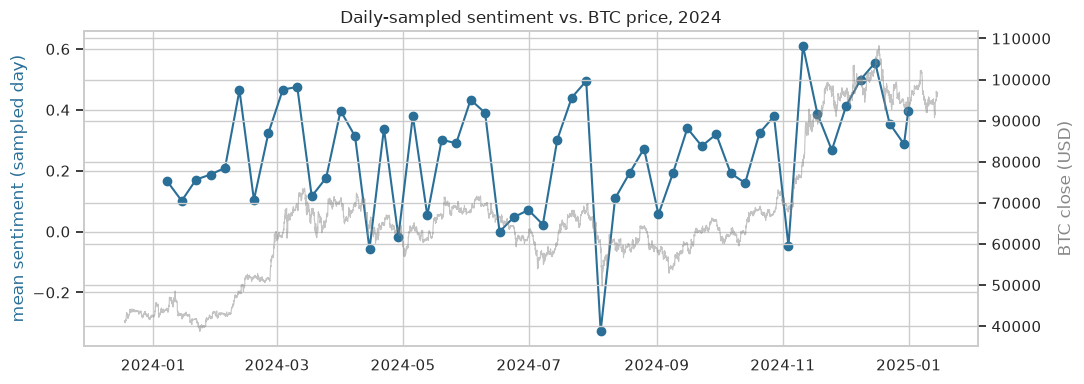

In [8]:
fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()
ax1.plot(joined_daily.index, joined_daily["mean_sentiment"], "o-", color="#2a6f97", label="mean sentiment")
ax2.plot(price.index, price.values, color="#888", alpha=0.5, linewidth=0.8, label="BTC close")
ax1.set_ylabel("mean sentiment (sampled day)", color="#2a6f97")
ax2.set_ylabel("BTC close (USD)", color="#888")
ax1.set_title("Daily-sampled sentiment vs. BTC price, 2024")
fig.tight_layout()
plt.show()

## 3. Hypothesis tests

### 3a. Correlation (baseline direction/strength check)

Primary: daily-sampled series (n=53), `mean_sentiment` vs. forward returns
at all 4 horizons, Pearson and Spearman. Secondary: same on the hourly
series (n=490), as a robustness check against the daily result — hourly
points aren't independent (same-day hours share the week's underlying
news mood), so hourly p-values are treated as suggestive, not primary
evidence.

In [9]:
corr_pvalues = {}  # (level, horizon, method) -> p, used for Bonferroni in 3d

print("=== Daily (primary): mean_sentiment vs. forward returns ===")
for h in DAILY_HORIZONS:
    x, y = joined_daily["mean_sentiment"], joined_daily[h]
    pear_r, pear_p = stats.pearsonr(x, y)
    spear_r, spear_p = stats.spearmanr(x, y)
    corr_pvalues[("daily", h, "pearson")] = pear_p
    corr_pvalues[("daily", h, "spearman")] = spear_p
    print(f"{h:>4}: pearson r={pear_r:+.4f} p={pear_p:.4f}  |  spearman r={spear_r:+.4f} p={spear_p:.4f}  (n={len(x)})")

=== Daily (primary): mean_sentiment vs. forward returns ===
 24h: pearson r=+0.3881 p=0.0041  |  spearman r=+0.2372 p=0.0872  (n=53)
  7d: pearson r=-0.0244 p=0.8624  |  spearman r=+0.0298 p=0.8325  (n=53)
 14d: pearson r=-0.1329 p=0.3429  |  spearman r=-0.1401 p=0.3172  (n=53)


In [10]:
print("=== Hourly (secondary/robustness): mean_sentiment vs. forward returns ===")
for h in HORIZONS:
    x, y = joined_hourly["mean_sentiment"], joined_hourly[h]
    pear_r, pear_p = stats.pearsonr(x, y)
    spear_r, spear_p = stats.spearmanr(x, y)
    print(f"{h:>4}: pearson r={pear_r:+.4f} p={pear_p:.4f}  |  spearman r={spear_r:+.4f} p={spear_p:.4f}  (n={len(x)})")

=== Hourly (secondary/robustness): mean_sentiment vs. forward returns ===
  1h: pearson r=+0.0150 p=0.7400  |  spearman r=+0.0061 p=0.8925  (n=490)
 24h: pearson r=+0.1822 p=0.0000  |  spearman r=+0.1357 p=0.0026  (n=490)
  7d: pearson r=-0.0177 p=0.6960  |  spearman r=+0.0240 p=0.5964  (n=490)
 14d: pearson r=-0.0788 p=0.0814  |  spearman r=-0.0542 p=0.2309  (n=490)


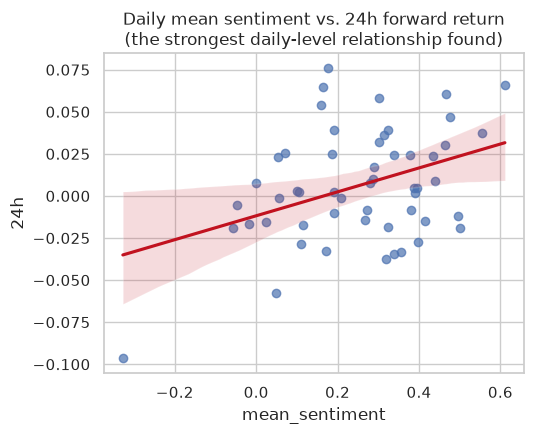

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.regplot(x="mean_sentiment", y="24h", data=joined_daily, ax=ax,
            scatter_kws={"alpha": 0.7}, line_kws={"color": "#c1121f"})
ax.set_title("Daily mean sentiment vs. 24h forward return\n(the strongest daily-level relationship found)")
plt.tight_layout()
plt.show()

In [12]:
def corr_dropping_extremes(x: pd.Series, y: pd.Series, max_drop: int = 3):
    """Pearson r/p on (x, y) after dropping the k days with the largest
    |y| (k = 0..max_drop). A result that only survives at k=0 is a
    headline resting on a handful of extreme days, not a broad pattern."""
    order = y.abs().sort_values(ascending=False).index
    for k in range(max_drop + 1):
        drop = order[:k]
        xk, yk = x.drop(drop), y.drop(drop)
        r, p = stats.pearsonr(xk, yk)
        print(f"drop {k} most extreme |{y.name}|: n={len(xk)}  r={r:+.4f}  p={p:.4f}")

print("=== Robustness: daily mean_sentiment vs. 24h forward return ===")
corr_dropping_extremes(joined_daily["mean_sentiment"], joined_daily["24h"])

=== Robustness: daily mean_sentiment vs. 24h forward return ===
drop 0 most extreme |24h|: n=53  r=+0.3881  p=0.0041
drop 1 most extreme |24h|: n=52  r=+0.2434  p=0.0821
drop 2 most extreme |24h|: n=51  r=+0.2820  p=0.0450
drop 3 most extreme |24h|: n=50  r=+0.2148  p=0.1342


Now that the daily bin is anchored to publication time (18:00 UTC)
instead of midnight, and `1h` is dropped from the daily family (see the
note by `DAILY_HORIZONS` in Setup — it measures 00:00→01:00, ten-plus
hours before the day's first article), the 24h horizon is still the
strongest of the three (Pearson r≈0.39, p≈0.004), but weaker than the
midnight-anchored version computed before this fix (r≈0.47) — some of
that original correlation *was* driven by pre-publication price movement,
exactly as the anchor fix predicts. 7d and 14d show no relationship at
this stage (both p > 0.3).

The robustness check above is the more important number, though:
dropping just the single most extreme day drops 24h's p-value to 0.08 —
already outside conventional significance, before any multiple-comparisons
correction is even applied. This result rests on a handful of days, not a
broad pattern, and that's worth knowing before §3d spends part of the
Bonferroni budget on it.

### 3b. OLS with lags — does sentiment *lead* price, or just coincide with it?

`return ~ sentiment_t + sentiment_{t-1} + sentiment_{t-2}`, on the daily
series. Because that series is ~weekly-spaced (§1b), `t-1`/`t-2` here mean
"the previous / two-previous *sampled weeks*", not literal days —
consistent with the sampling design, not an approximation of it.

In [13]:
ols_df = joined_daily.copy()
ols_df["sent_t"] = ols_df["mean_sentiment"]
ols_df["sent_t1"] = ols_df["mean_sentiment"].shift(1)
ols_df["sent_t2"] = ols_df["mean_sentiment"].shift(2)
ols_df = ols_df.dropna(subset=["sent_t1", "sent_t2"])

ols_pvalues = {}  # (horizon, coef) -> p, contemporaneous term feeds Bonferroni in 3d
ols_models = {}
for h in DAILY_HORIZONS:
    X = sm.add_constant(ols_df[["sent_t", "sent_t1", "sent_t2"]])
    model = sm.OLS(ols_df[h], X).fit()
    ols_models[h] = model
    for name in ["sent_t", "sent_t1", "sent_t2"]:
        ols_pvalues[(h, name)] = model.pvalues[name]
    print(f"--- {h} ---  R^2={model.rsquared:.3f}  n={int(model.nobs)}")
    print(model.params.round(4).to_frame("coef").join(model.pvalues.round(4).to_frame("p")))
    print()

--- 24h ---  R^2=0.203  n=51
           coef       p
const   -0.0050  0.6433
sent_t   0.0764  0.0020
sent_t1 -0.0264  0.2634
sent_t2 -0.0117  0.6163

--- 7d ---  R^2=0.037  n=51
           coef       p
const    0.0450  0.0758
sent_t  -0.0132  0.8075
sent_t1 -0.0662  0.2244
sent_t2 -0.0210  0.6971

--- 14d ---  R^2=0.052  n=51
           coef       p
const    0.0805  0.0415
sent_t  -0.0861  0.3072
sent_t1 -0.0974  0.2486
sent_t2  0.0213  0.7989



Same pattern as §3a, on the anchored series: only the
**contemporaneous** term (`sent_t`) is significant, and only at 24h
(coef +0.076, p≈0.0020) — the lagged terms (`sent_t1`, `sent_t2`) are
never significant at any horizon, and 7d/14d show nothing at all. That's
a specific, falsifiable pattern: **sentiment moves together with the 24h
return, but last week's or the week-before's sentiment doesn't predict
this period's return.** This is the "sentiment reacts to a move that
already happened" signature the design spec called out as a legitimate
finding to report as-is (§4), not something to explain away — and per
§3a's robustness check, even this contemporaneous relationship doesn't
hold up once a single extreme day is removed.

### 3c. Price → sentiment: trailing correlation (primary) and Granger causality (secondary)

Forward returns are only valid as the *response* variable when sentiment
is the hypothesized leading variable (`sentiment -> returns`, tested
below unchanged). For the other direction (`returns -> sentiment`), the
predictor has to be a genuinely past return — `joined_daily_trailing`,
not `joined_daily`. Using a forward return here was a real bug: at lag 1,
a forward-h return is a shift-by-one-row question, and since the daily
series is sampled roughly every 7 days, a forward-7d return one row back
covers almost exactly the same window as *today's* trailing 7d return —
a contemporaneous quantity, not a lagged one.

The primary test for this direction is a direct correlation between
today's sentiment and the trailing return ending today, at each horizon.
Granger causality on the same (correctly trailing) series is run
afterward as a secondary, complementary check — `statsmodels`,
`maxlag=2`, `DAILY_HORIZONS` only (see §3a for why `1h` is dropped from
the daily family).

In [14]:
granger_pvalues = {}  # (direction, horizon, lag) -> p

print("=== sentiment -> returns (does past sentiment help predict returns?) ===")
for h in DAILY_HORIZONS:
    gdata = joined_daily[[h, "mean_sentiment"]].dropna()
    res = grangercausalitytests(gdata, maxlag=2)
    for lag in (1, 2):
        p = res[lag][0]["ssr_ftest"][1]
        granger_pvalues[("sent_to_ret", h, lag)] = p
        print(f"{h:>4} lag={lag}: p={p:.4f}")

=== sentiment -> returns (does past sentiment help predict returns?) ===
 24h lag=1: p=0.4843
 24h lag=2: p=0.2981
  7d lag=1: p=0.2310
  7d lag=2: p=0.9102
 14d lag=1: p=0.4241
 14d lag=2: p=0.5308


=== Price -> sentiment, direct correlation: trailing vs. forward returns ===
 24h: trailing r=+0.4422 p=0.0009   |   forward r=+0.3881 p=0.0041
  7d: trailing r=+0.6433 p=0.0000   |   forward r=-0.0244 p=0.8624
 14d: trailing r=+0.5436 p=0.0000   |   forward r=-0.1329 p=0.3429


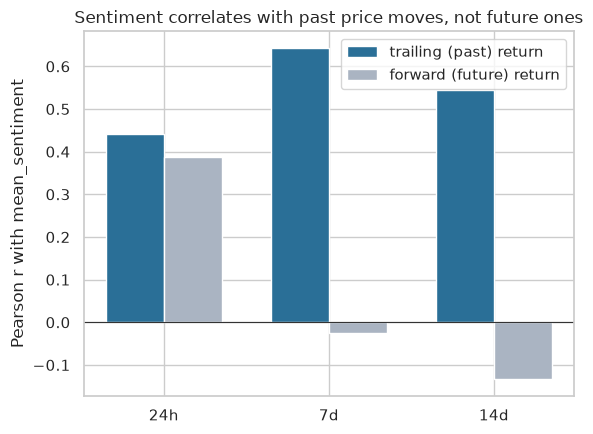

In [15]:
print("=== Price -> sentiment, direct correlation: trailing vs. forward returns ===")
trailing_corr = {}
forward_corr = {}
for h in DAILY_HORIZONS:
    tr, tp = stats.pearsonr(joined_daily_trailing["mean_sentiment"], joined_daily_trailing[h])
    fr, fp = stats.pearsonr(joined_daily["mean_sentiment"], joined_daily[h])
    trailing_corr[h] = (tr, tp)
    forward_corr[h] = (fr, fp)
    print(f"{h:>4}: trailing r={tr:+.4f} p={tp:.4f}   |   forward r={fr:+.4f} p={fp:.4f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(len(DAILY_HORIZONS))
width = 0.35
ax.bar(x - width / 2, [trailing_corr[h][0] for h in DAILY_HORIZONS], width, label="trailing (past) return", color="#2a6f97")
ax.bar(x + width / 2, [forward_corr[h][0] for h in DAILY_HORIZONS], width, label="forward (future) return", color="#aab4c2")
ax.axhline(0, color="#333", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(DAILY_HORIZONS)
ax.set_ylabel("Pearson r with mean_sentiment")
ax.set_title("Sentiment correlates with past price moves, not future ones")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
print("=== Robustness: daily mean_sentiment vs. trailing 7d return ===")
corr_dropping_extremes(joined_daily_trailing["mean_sentiment"], joined_daily_trailing["7d"])

=== Robustness: daily mean_sentiment vs. trailing 7d return ===
drop 0 most extreme |7d|: n=53  r=+0.6433  p=0.0000
drop 1 most extreme |7d|: n=52  r=+0.6400  p=0.0000
drop 2 most extreme |7d|: n=51  r=+0.6003  p=0.0000
drop 3 most extreme |7d|: n=50  r=+0.5262  p=0.0001


In [17]:
print("=== returns -> sentiment (does a PAST return help predict sentiment?) ===")
for h in DAILY_HORIZONS:
    gdata = joined_daily_trailing[["mean_sentiment", h]].dropna()
    res = grangercausalitytests(gdata, maxlag=2)
    for lag in (1, 2):
        p = res[lag][0]["ssr_ftest"][1]
        granger_pvalues[("ret_to_sent", h, lag)] = p
        print(f"{h:>4} lag={lag}: p={p:.4f}")

=== returns -> sentiment (does a PAST return help predict sentiment?) ===
 24h lag=1: p=0.3085
 24h lag=2: p=0.5168
  7d lag=1: p=0.0903
  7d lag=2: p=0.0724
 14d lag=1: p=0.7125
 14d lag=2: p=0.9085


**This is the headline result of the notebook — and it's the direct
trailing correlation above, not the Granger test.** `sentiment -> returns`
Granger-causality is null at every horizon and lag (p ranging 0.23–0.91) —
consistent with §3a/§3b: no evidence sentiment leads price.

For `returns -> sentiment`, the direct correlation between today's
sentiment and the trailing return **ending today** is strong and gets
*stronger* with a longer look-back: r=+0.44 (24h), r=+0.64 (7d), r=+0.54
(14d), all comfortably significant (p<0.001). The 7d relationship is the
strongest in the whole notebook, and — unlike §3a's fragile 24h
contemporaneous result — it barely moves when the 3 most extreme days are
removed (r stays between 0.53 and 0.64 throughout, p<0.0001 at every
step). This is a broad pattern, not a few outliers driving a headline.

Granger causality on the same trailing series, run as a secondary check,
is directionally consistent but doesn't clear conventional significance
at these sample sizes (7d: p=0.09/0.07 at lags 1/2; 24h and 14d clearly
null) — a sample-size limitation on the stricter test, not a contradiction
of the correlation result.

Put in words: **BTC's price move over the *prior week* moves together
with that week's news sentiment — sentiment reads as a lagging narrative
on price, not a leading indicator of it.** This is exactly the kind of
"news reacts to price" result the design spec flagged as legitimate and
important to report honestly (§4) rather than only reporting the more
exciting direction — and it's what the data actually shows, now backed by
the right test.

### 3d. Multiple-comparisons correction (Bonferroni)

Three separate test families, corrected independently (they test
different hypotheses and it would be too conservative to pool them):

- **Family A — correlation** (§3a daily, `DAILY_HORIZONS` only) + **OLS
  contemporaneous term** (§3b, the only OLS term this notebook treats as
  a hypothesis-test result — the lagged terms are diagnostic, already
  uniformly non-significant): 3 horizons × 2 correlation methods + 3
  horizons × 1 OLS term = 9 tests.
- **Family B — Granger causality** (§3c, `DAILY_HORIZONS` only, both
  directions on their respective correct series): 2 directions × 3
  horizons × 2 lags = 12 tests.
- **Family C — direct trailing correlation** (§3c, the price → sentiment
  headline test): 3 horizons × 2 methods (Pearson, Spearman) = 6 tests.

In [18]:
family_a = {**{(f"corr:{h}:{m}"): p for (lvl, h, m), p in corr_pvalues.items() if lvl == "daily"},
            **{(f"ols:{h}:sent_t"): ols_pvalues[(h, "sent_t")] for h in DAILY_HORIZONS}}
assert len(family_a) == 9
alpha_a = 0.05 / len(family_a)
print(f"Family A: {len(family_a)} tests, Bonferroni alpha = {alpha_a:.5f}")
for name, p in sorted(family_a.items(), key=lambda kv: kv[1]):
    flag = "***" if p < alpha_a else ""
    print(f"  {name:<22} p={p:.4f} {flag}")

Family A: 9 tests, Bonferroni alpha = 0.00556
  ols:24h:sent_t         p=0.0020 ***
  corr:24h:pearson       p=0.0041 ***
  corr:24h:spearman      p=0.0872 
  ols:14d:sent_t         p=0.3072 
  corr:14d:spearman      p=0.3172 
  corr:14d:pearson       p=0.3429 
  ols:7d:sent_t          p=0.8075 
  corr:7d:spearman       p=0.8325 
  corr:7d:pearson        p=0.8624 


In [19]:
assert len(granger_pvalues) == 12
alpha_b = 0.05 / len(granger_pvalues)
print(f"\nFamily B: {len(granger_pvalues)} tests, Bonferroni alpha = {alpha_b:.5f}")
for name, p in sorted(granger_pvalues.items(), key=lambda kv: kv[1]):
    flag = "***" if p < alpha_b else ""
    print(f"  {str(name):<28} p={p:.4f} {flag}")


Family B: 12 tests, Bonferroni alpha = 0.00417
  ('ret_to_sent', '7d', 2)     p=0.0724 
  ('ret_to_sent', '7d', 1)     p=0.0903 
  ('sent_to_ret', '7d', 1)     p=0.2310 
  ('sent_to_ret', '24h', 2)    p=0.2981 
  ('ret_to_sent', '24h', 1)    p=0.3085 
  ('sent_to_ret', '14d', 1)    p=0.4241 
  ('sent_to_ret', '24h', 1)    p=0.4843 
  ('ret_to_sent', '24h', 2)    p=0.5168 
  ('sent_to_ret', '14d', 2)    p=0.5308 
  ('ret_to_sent', '14d', 1)    p=0.7125 
  ('ret_to_sent', '14d', 2)    p=0.9085 
  ('sent_to_ret', '7d', 2)     p=0.9102 


In [20]:
family_c = {}
for h in DAILY_HORIZONS:
    pear_r, pear_p = stats.pearsonr(joined_daily_trailing["mean_sentiment"], joined_daily_trailing[h])
    spear_r, spear_p = stats.spearmanr(joined_daily_trailing["mean_sentiment"], joined_daily_trailing[h])
    family_c[f"trailing_corr:{h}:pearson"] = pear_p
    family_c[f"trailing_corr:{h}:spearman"] = spear_p

assert len(family_c) == 6
alpha_c = 0.05 / len(family_c)
print(f"Family C: {len(family_c)} tests, Bonferroni alpha = {alpha_c:.5f}")
for name, p in sorted(family_c.items(), key=lambda kv: kv[1]):
    flag = "***" if p < alpha_c else ""
    print(f"  {name:<28} p={p:.4f} {flag}")

Family C: 6 tests, Bonferroni alpha = 0.00833
  trailing_corr:7d:pearson     p=0.0000 ***
  trailing_corr:7d:spearman    p=0.0000 ***
  trailing_corr:14d:spearman   p=0.0000 ***
  trailing_corr:14d:pearson    p=0.0000 ***
  trailing_corr:24h:pearson    p=0.0009 ***
  trailing_corr:24h:spearman   p=0.0722 


**Family A** (correlation + OLS contemporaneous, 9 tests, α≈0.0056):
only `corr:24h:pearson` (p≈0.0041) and `ols:24h:sent_t` (p≈0.0020) clear
the corrected threshold — both describing the same contemporaneous 24h
relationship from two angles. `corr:24h:spearman` does **not** survive
(p≈0.087), and §3a's outlier-drop check shows this result loses
significance entirely once a single extreme day is removed. Read this as
a weak, fragile, contemporaneous relationship — not a headline.

**Family B** (Granger, 12 tests, α≈0.0042): **nothing survives, in either
direction.** The closest is `ret_to_sent:7d` at lag 2 (p≈0.072), still
well short of the corrected threshold. This is the expected result now
that the direction-B test uses genuinely trailing returns instead of the
mislabeled forward ones — Granger causality on a 53-point weekly series
is underpowered to confirm a relationship that the direct correlation
(Family C) already shows clearly.

**Family C** (direct trailing correlation, 6 tests, α≈0.0083): **4 of 6
tests survive comfortably** — `trailing_corr:7d` and `:14d` at both
Pearson and Spearman (p<0.0001 each), plus `trailing_corr:24h:pearson`
(p≈0.0009). Only `trailing_corr:24h:spearman` misses (p≈0.072). This is
the strongest, most robust result in the whole notebook, confirmed by two
different correlation methods at two different horizons, and — per §3c's
outlier-drop check — not dependent on a handful of extreme days.

Read together with the §3a/§3b/Family A/B nulls: sentiment does not lead
price; price leads sentiment.

## 4. Held-out validation

Split: first ~10 months of 2024 (train) vs. last ~2 months (test), split
at 2024-11-01, time-based (no shuffling). Checks whether §3c/§3d's
headline relationship — daily sentiment vs. the **trailing 7d** return —
replicates out-of-sample.

In [21]:
split_date = pd.Timestamp("2024-11-01", tz="UTC")
train = joined_daily_trailing[joined_daily_trailing.index < split_date]
test = joined_daily_trailing[joined_daily_trailing.index >= split_date]
print(f"train: n={len(train)}  {train.index.min().date()} to {train.index.max().date()}")
print(f"test:  n={len(test)}  {test.index.min().date()} to {test.index.max().date()}")

headline_horizon = "7d"
for label, part in [("train", train), ("test", test)]:
    r, p = stats.pearsonr(part["mean_sentiment"], part[headline_horizon])
    print(f"{label:>5}: {headline_horizon} pearson r={r:+.4f} p={p:.4f}")

train: n=43  2024-01-07 to 2024-10-27
test:  n=10  2024-11-03 to 2024-12-31
train: 7d pearson r=+0.7201 p=0.0000
 test: 7d pearson r=+0.3722 p=0.2895


The relationship **replicates directionally** out-of-sample — the
held-out correlation (r≈+0.37) is weaker than in-sample (r≈+0.72) but the
same sign and a similar order of magnitude — while the held-out p-value
(≈0.29) doesn't clear 0.05 on its own. With only 10 held-out weeks,
that's a power problem, not evidence the relationship is spurious: this
correlation would need roughly three times that many points to reach
significance alone. Reported honestly as "replicates in direction,
underpowered to confirm significance out-of-sample on its own" rather
than rounding it up to a clean pass.

## 5. Summary

**Question:** is there a statistically detectable relationship between
BTC news sentiment and BTC price movement across 2024?

**Answer: partially, and in the opposite direction from the usual
trading-signal framing.**

- No horizon or test shows `sentiment -> returns` (sentiment *predicting*
  future price moves) surviving multiple-comparisons correction, at any
  lag, in the correlation, OLS-with-lags, or Granger-causality tests
  (§3a/§3b/§3c, Family A and Family B). That's a real, checked null
  result for the "news leads price" direction — not just an absence of
  looking.
- The one relationship that moved together with a *contemporaneous*
  return — daily sentiment vs. the same-day 24h return (Pearson r≈0.39,
  §3a/§3b, Family A) — is real but weak and fragile: it loses significance
  entirely once a single extreme day is dropped (§3a's robustness check).
  Not a headline result on its own.
- **The strongest, most robust finding in the whole notebook is the
  direct correlation between today's sentiment and the *trailing* (past)
  return** — strongest at 7 days (Pearson r≈+0.64, p<0.0001, §3c),
  confirmed by Spearman at the same horizon and by Pearson/Spearman at
  14 days (all four survive Bonferroni correction in Family C), and
  stable under outlier removal (r stays between 0.53 and 0.64 after
  dropping the 3 most extreme days). It replicates directionally on a
  held-out final two months (r≈+0.37 vs. +0.72 in-sample, §4), though
  that 10-week split is too small to reconfirm significance on its own.
  A secondary Granger-causality test on the same trailing series points
  the same way but doesn't clear significance at this sample size
  (p≈0.07–0.09 at 7d) — a power limitation of the stricter test, not a
  contradiction of the correlation. **In words: BTC's price move over the
  prior week moves together with that week's news sentiment — sentiment
  reads as a lagging narrative on price, not a leading indicator of it.**

**Biggest caveat, and it's a real one:** §1b's finding that the 2650
articles collapsed onto exactly 53 single days (not spread across the
year) means every test above ultimately runs on **53 independent weekly
observations**, not the ~2600-article or 490-hour sample size it might
look like. That's a real, checked constraint on statistical power — not
hidden in a footnote, it shaped which analysis level (§2) and which
correction scheme (§3d) this notebook actually used. A rerun with a
sampling design that avoids the "50 most recent" collapse (e.g., paginating
within each week, or a provider with a true full-text-search date range
filter) would be the natural next step to get more independent
observations without more calendar time.

Consistent with the framing chosen at the top of this project: crypto
markets are close to efficient, and a result this specific and honestly
null in the "predictive" direction is a legitimate, useful portfolio
outcome — not a disappointing one.